# Research Paper Plots
Visualize TensorBoard results with custom legends, axis labels, and publication-quality styling.

## 0. Configuration — edit this cell to customize everything

In [1]:
from pathlib import Path

# ── Run registry ──────────────────────────────────────────────────────────────
LOGDIR_ROOT = Path("/home/spotai_large/asharma/safe-dreamer/logdir")
RUNS = {
    "CNN": {
        "2026-03-12/15-09-09": "Dynamic + Floor",
    },
    "Multimodal": {
        "2026-03-12/16-30-45": "Dynamic + Floor",
    },
}

SETTINGS = ["Dynamic + Floor"]

# ── Colors: one color per model ───────────────────────────────────────────────
MODEL_COLORS = {
    "CNN":        "#1A6EBD",   # blue
    "Multimodal": "#CC0000",   # red
}

# ── Figure style ──────────────────────────────────────────────────────────────
FIGSIZE      = (6, 4)
DPI          = 600
SMOOTHING    = 0.6
ALPHA_RAW    = 0.35
LINEWIDTH    = 2.0
FONT_SIZE    = 15
LEGEND_SIZE  = 11
LEGEND_LOC   = "lower right"

# ── Y-axis range for episode return plots ─────────────────────────────────────
RETURN_YLIM  = (0, 1000)

# ── X-axis ────────────────────────────────────────────────────────────────────
X_SCALE      = "million_steps"
X_MAX        = None

# ── Save directory ────────────────────────────────────────────────────────────
SAVE_DIR     = Path("figures")
SAVE_DIR.mkdir(exist_ok=True)
SAVE_FMT     = "pdf"  # 'pdf', 'png', 'svg'

print("Config loaded. Models:", list(RUNS.keys()))
print("Settings per model:", {m: list(v.values()) for m, v in RUNS.items()})


Config loaded. Models: ['CNN', 'Multimodal']
Settings per model: {'CNN': ['Dynamic + Floor'], 'Multimodal': ['Dynamic + Floor']}


## 1. Imports & helpers

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

# ── Publication-quality rcParams ──────────────────────────────────────────────
matplotlib.rcParams.update({
    "font.family":        "serif",
    "font.serif":         ["TeX Gyre Pagella", "DejaVu Serif"],
    "mathtext.fontset":   "stix",
    "font.size":          FONT_SIZE,
    "axes.titlesize":     FONT_SIZE,
    "axes.labelsize":     FONT_SIZE,
    "xtick.labelsize":    FONT_SIZE - 1,
    "ytick.labelsize":    FONT_SIZE - 1,
    "legend.fontsize":    LEGEND_SIZE,
    "lines.linewidth":    LINEWIDTH,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.grid":          True,
    "grid.alpha":         0.3,
    "grid.linestyle":     "--",
    "figure.dpi":         100,
    "savefig.dpi":        DPI,
    "savefig.bbox":       "tight",
})

# ── Load all runs once ────────────────────────────────────────────────────────
# _accumulators[(model, setting)] = EventAccumulator
_accumulators = {}
for model, setting_runs in RUNS.items():
    for rel_path, setting in setting_runs.items():
        path = LOGDIR_ROOT / rel_path
        ea = EventAccumulator(str(path), size_guidance={"scalars": 0})
        ea.Reload()
        _accumulators[(model, setting)] = ea
        tags = ea.Tags()["scalars"]
        print(f"  {model:15s}  {setting:20s}  {len(tags)} scalar tags")

print("\nAll runs loaded.")

# ── Helper: load a scalar tag into a DataFrame ────────────────────────────────
def load_scalar(model: str, setting: str, tag: str) -> pd.DataFrame | None:
    ea = _accumulators.get((model, setting))
    if ea is None or tag not in ea.Tags()["scalars"]:
        return None
    events = ea.Scalars(tag)
    df = pd.DataFrame({"step": [e.step for e in events],
                       "value": [e.value for e in events]})
    df["x"] = df["step"] / 1e6 if X_SCALE == "million_steps" else df["step"]
    if X_MAX is not None:
        df = df[df["x"] <= X_MAX]
    return df

# ── Helper: EMA smoothing ─────────────────────────────────────────────────────
def ema(values, alpha=SMOOTHING):
    out, s = [], None
    for v in values:
        s = v if s is None else alpha * s + (1 - alpha) * v
        out.append(s)
    return np.array(out)

# ── Helper: plot one tag, all models, for a given setting ────────────────────
def plot_setting(
    tag: str,
    setting: str,
    ylabel: str = "",
    xlabel: str = None,
    title: str = None,
    ylim: tuple = None,
    xlim: tuple = None,
    ax: plt.Axes = None,
):
    _xlabel = xlabel if xlabel is not None else (
        "Environment Steps (M)" if X_SCALE == "million_steps" else "Steps")
    _title = title if title is not None else setting

    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=FIGSIZE)

    for model, color in MODEL_COLORS.items():
        df = load_scalar(model, setting, tag)
        if df is None or df.empty:
            print(f"  [skip] {model} / {setting}: tag '{tag}' not found")
            continue
        raw    = df["value"].to_numpy()
        smooth = ema(raw)
        ax.plot(df["x"], raw,    color=color, alpha=ALPHA_RAW, linewidth=1)
        ax.plot(df["x"], smooth, color=color, linewidth=LINEWIDTH, label=model)

    ax.set_xlabel(_xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(_title)
    if ylim: ax.set_ylim(ylim)
    if xlim: ax.set_xlim(xlim)
    ax.legend(loc=LEGEND_LOC)

    if own_fig:
        plt.tight_layout()
        plt.show()

print("Helpers ready.")


  CNN              Dynamic + Floor       47 scalar tags
  Multimodal       Dynamic + Floor       52 scalar tags

All runs loaded.
Helpers ready.


## 2. Eval Score CNN vs. Multimodal

Saved → figures/paper_cnn_vs_multimodal.pdf


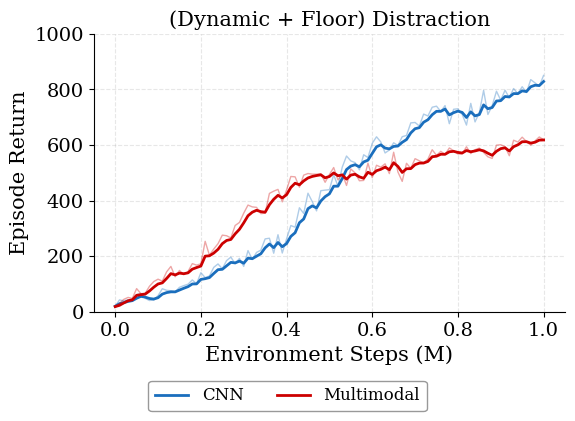

In [3]:
# ── Paper figure: single plot ──────────────────────────────────────────────
PAPER_TAG = "episode/eval_score"
SETTING   = "Dynamic + Floor"

fig, ax = plt.subplots(1, 1, figsize=(6, 4))

plot_setting(tag=PAPER_TAG, setting=SETTING, ylabel="Episode Return",
             title="(Dynamic + Floor) Distraction", ylim=RETURN_YLIM, ax=ax)

handles, labels_l = ax.get_legend_handles_labels()
ax.get_legend().remove()
fig.legend(handles, labels_l, loc="lower center", ncol=len(RUNS),
           fontsize=LEGEND_SIZE + 1, bbox_to_anchor=(0.5, -0.08),
           frameon=True, edgecolor="gray")

plt.tight_layout()
path = SAVE_DIR / f"paper_cnn_vs_multimodal.{SAVE_FMT}"
fig.savefig(path, bbox_inches="tight")
print(f"Saved → {path}")
plt.show()


## 3. Episode reward (train)

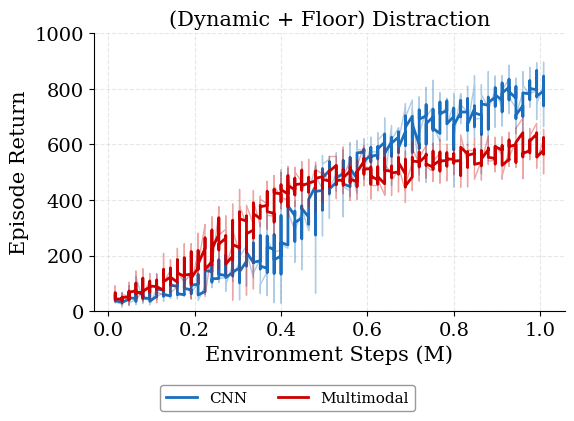

In [4]:
fig, ax = plt.subplots(1, 1, figsize=FIGSIZE)

plot_setting(tag="episode/score", setting="Dynamic + Floor", ylabel="Episode Return",
             title="(Dynamic + Floor) Distraction", ylim=RETURN_YLIM, ax=ax)

handles, labels_l = ax.get_legend_handles_labels()
ax.get_legend().remove()
fig.legend(handles, labels_l, loc="lower center", ncol=len(RUNS), fontsize=LEGEND_SIZE,
           bbox_to_anchor=(0.5, -0.08), frameon=True, edgecolor="gray")
plt.tight_layout()
fig.savefig(SAVE_DIR / f"train_return.{SAVE_FMT}", bbox_inches="tight")
plt.show()


## 4. World model losses

Saved → figures/world_model_losses.pdf


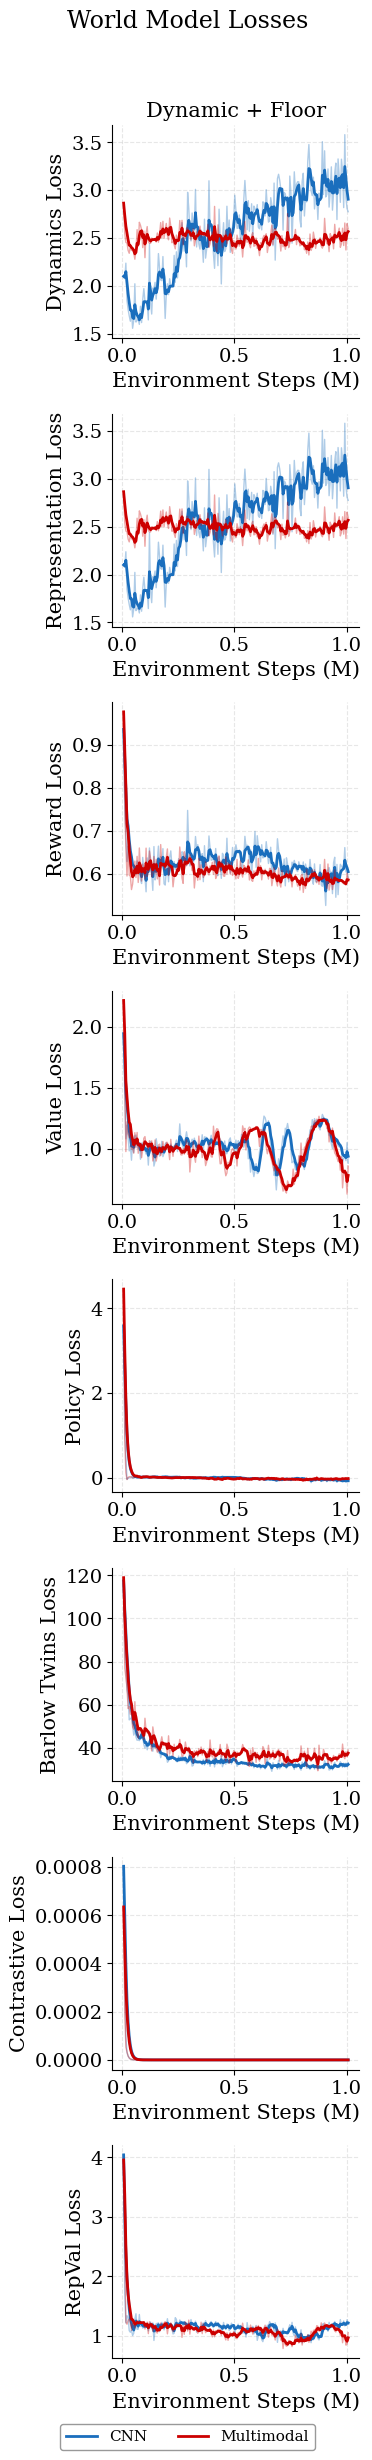

In [17]:
loss_tags = {
    "train/loss/dyn":    "Dynamics Loss",
    "train/loss/rep":    "Representation Loss",
    "train/loss/rew":    "Reward Loss",
    "train/loss/value":  "Value Loss",
    "train/loss/policy": "Policy Loss",
    "train/loss/barlow": "Barlow Twins Loss",
    "train/loss/con":    "Contrastive Loss",
    "train/loss/repval": "RepVal Loss",
}

# One row per loss tag, one column per setting
nrows, ncols = len(loss_tags), len(SETTINGS)
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3), squeeze=False)

for row, (tag, ylabel) in enumerate(loss_tags.items()):
    for col, setting in enumerate(SETTINGS):
        ax = axes[row][col]
        title = setting if row == 0 else ""
        plot_setting(tag=tag, setting=setting, ylabel=ylabel if col == 0 else "", title=title, ax=ax)
        leg = ax.get_legend()
        if leg: leg.remove()

handles, labels_l = axes[0][0].get_legend_handles_labels()
fig.legend(handles, labels_l, loc="lower center", ncol=len(RUNS), fontsize=LEGEND_SIZE,
           bbox_to_anchor=(0.5, -0.01), frameon=True, edgecolor="gray")
plt.suptitle("World Model Losses", fontsize=FONT_SIZE + 2, y=1.01)
plt.tight_layout()
fig.savefig(SAVE_DIR / f"world_model_losses.{SAVE_FMT}", bbox_inches="tight")
print(f"Saved → {SAVE_DIR}/world_model_losses.{SAVE_FMT}")
plt.show()


## 5. Actor-Critic diagnostics

Saved → figures/actor_critic.pdf


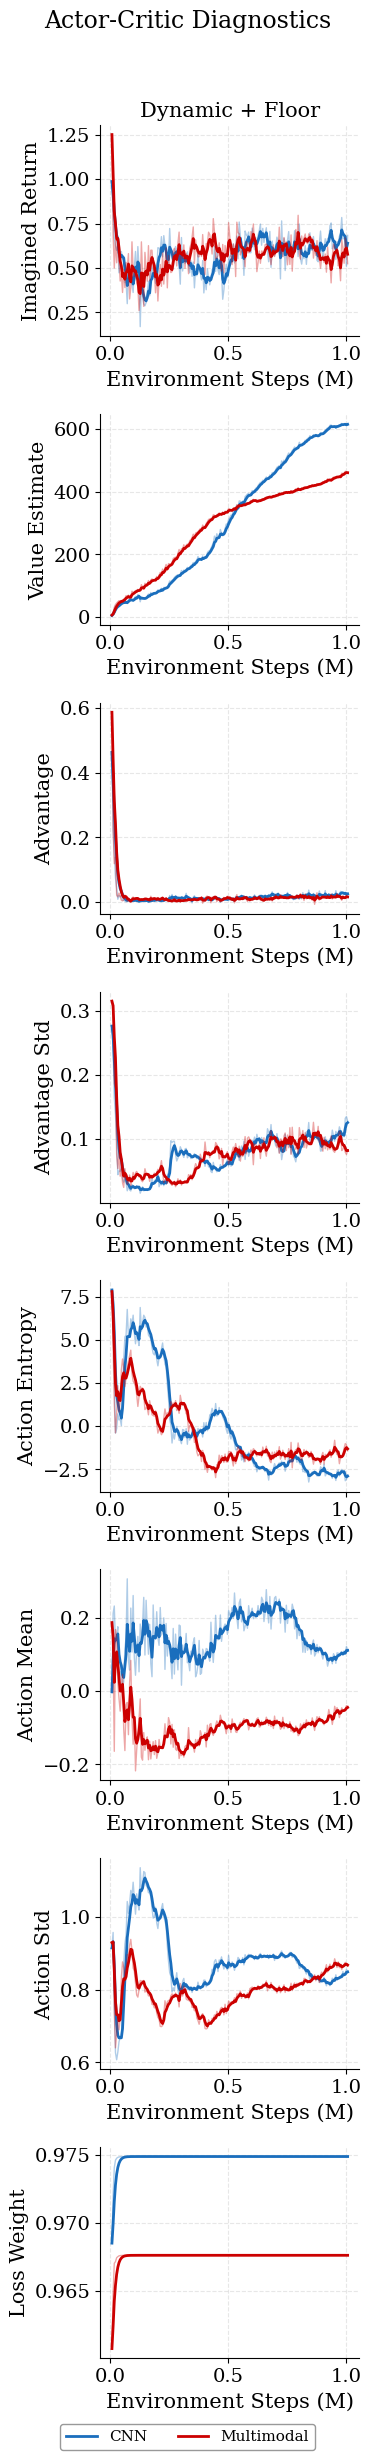

In [13]:
ac_tags = {
    "train/ret":             "Imagined Return",
    "train/val":             "Value Estimate",
    "train/adv":             "Advantage",
    "train/adv_std":         "Advantage Std",
    "train/action_entropy":  "Action Entropy",
    "train/action_mean":     "Action Mean",
    "train/action_std":      "Action Std",
    "train/weight":          "Loss Weight",
}

nrows, ncols = len(ac_tags), len(SETTINGS)
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3), squeeze=False)

for row, (tag, ylabel) in enumerate(ac_tags.items()):
    for col, setting in enumerate(SETTINGS):
        ax = axes[row][col]
        title = setting if row == 0 else ""
        plot_setting(tag=tag, setting=setting, ylabel=ylabel if col == 0 else "", title=title, ax=ax)
        leg = ax.get_legend()
        if leg: leg.remove()

handles, labels_l = axes[0][0].get_legend_handles_labels()
fig.legend(handles, labels_l, loc="lower center", ncol=len(RUNS), fontsize=LEGEND_SIZE,
           bbox_to_anchor=(0.5, -0.01), frameon=True, edgecolor="gray")
plt.suptitle("Actor-Critic Diagnostics", fontsize=FONT_SIZE + 2, y=1.01)
plt.tight_layout()
fig.savefig(SAVE_DIR / f"actor_critic.{SAVE_FMT}", bbox_inches="tight")
print(f"Saved → {SAVE_DIR}/actor_critic.{SAVE_FMT}")
plt.show()


## 7. Text gate diagnostics (multimodal runs only)

  [skip] CNN / Dynamic + Floor: tag 'train/encoder/text_gate_mean' not found
  [skip] CNN / Dynamic + Floor: tag 'train/encoder/text_gate_std' not found
  [skip] CNN / Dynamic + Floor: tag 'train/encoder/text_gate_final_bias_mean' not found
  [skip] CNN / Dynamic + Floor: tag 'train/encoder/text_gate_final_weight_norm' not found
  [skip] CNN / Dynamic + Floor: tag 'train/encoder/text_proj_weight_norm' not found


Saved → figures/text_gate.pdf


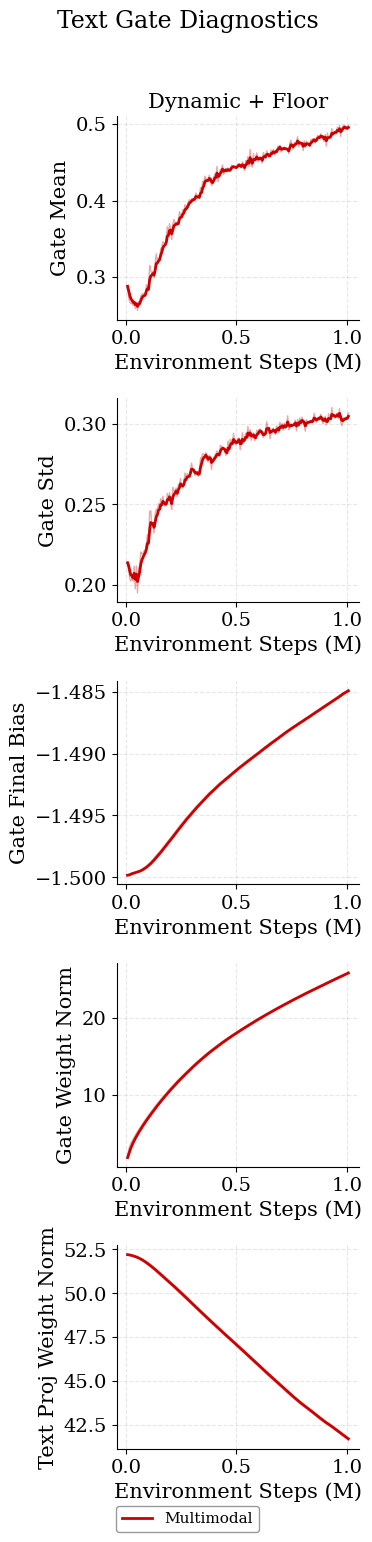

In [18]:
# ── Filter to only runs that have encoder tags ────────────────────────────────
mm_keys = [(m, s) for (m, s), ea in _accumulators.items()
           if "train/encoder/text_gate_mean" in ea.Tags()["scalars"]]

if not mm_keys:
    print("No runs with encoder tags found. Skipping.")
else:
    gate_tags = {
        "train/encoder/text_gate_mean":              "Gate Mean",
        "train/encoder/text_gate_std":               "Gate Std",
        "train/encoder/text_gate_final_bias_mean":   "Gate Final Bias",
        "train/encoder/text_gate_final_weight_norm": "Gate Weight Norm",
        "train/encoder/text_proj_weight_norm":       "Text Proj Weight Norm",
    }
    mm_settings = sorted({s for _, s in mm_keys})

    nrows, ncols = len(gate_tags), len(mm_settings)
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3), squeeze=False)

    for row, (tag, ylabel) in enumerate(gate_tags.items()):
        for col, setting in enumerate(mm_settings):
            ax = axes[row][col]
            title = setting if row == 0 else ""
            plot_setting(tag=tag, setting=setting, ylabel=ylabel if col == 0 else "", title=title, ax=ax)
            leg = ax.get_legend()
            if leg: leg.remove()

    handles, labels_l = axes[0][0].get_legend_handles_labels()
    fig.legend(handles, labels_l, loc="lower center", ncol=len(RUNS), fontsize=LEGEND_SIZE,
               bbox_to_anchor=(0.5, -0.01), frameon=True, edgecolor="gray")
    plt.suptitle("Text Gate Diagnostics", fontsize=FONT_SIZE + 2, y=1.01)
    plt.tight_layout()
    fig.savefig(SAVE_DIR / f"text_gate.{SAVE_FMT}", bbox_inches="tight")
    print(f"Saved → {SAVE_DIR}/text_gate.{SAVE_FMT}")
    plt.show()


## 8. Value / return distribution

Saved → figures/return_distribution.pdf


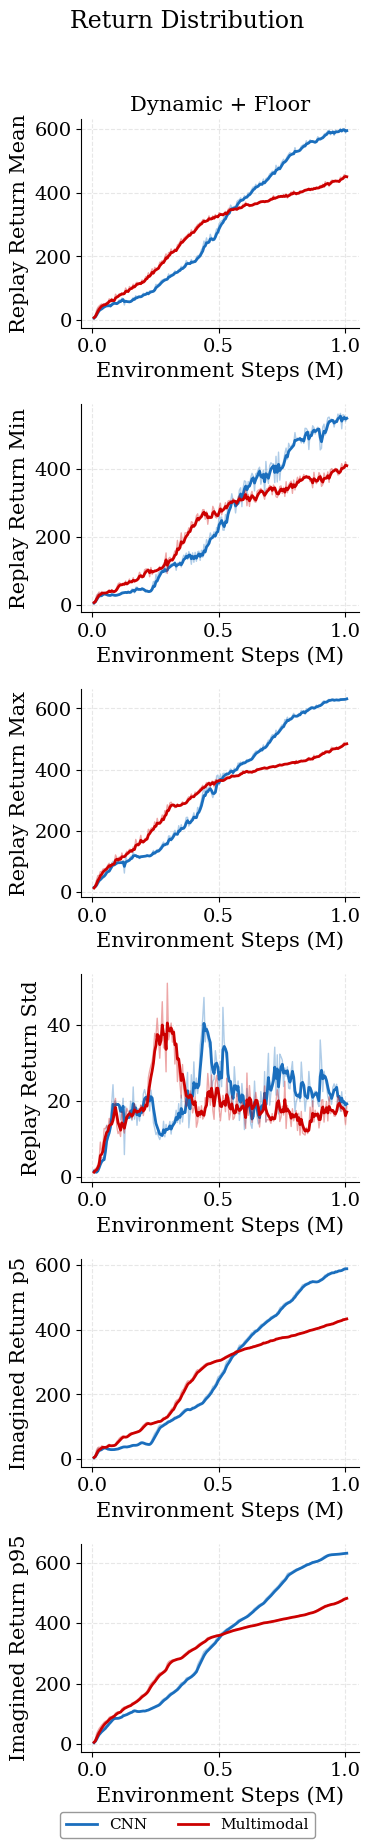

In [19]:
ret_tags = {
    "train/ret_replay_mean": "Replay Return Mean",
    "train/ret_replay_min":  "Replay Return Min",
    "train/ret_replay_max":  "Replay Return Max",
    "train/ret_replay_std":  "Replay Return Std",
    "train/ret_005":         "Imagined Return p5",
    "train/ret_095":         "Imagined Return p95",
}

nrows, ncols = len(ret_tags), len(SETTINGS)
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3), squeeze=False)

for row, (tag, ylabel) in enumerate(ret_tags.items()):
    for col, setting in enumerate(SETTINGS):
        ax = axes[row][col]
        title = setting if row == 0 else ""
        plot_setting(tag=tag, setting=setting, ylabel=ylabel if col == 0 else "", title=title, ax=ax)
        leg = ax.get_legend()
        if leg: leg.remove()

handles, labels_l = axes[0][0].get_legend_handles_labels()
fig.legend(handles, labels_l, loc="lower center", ncol=len(RUNS), fontsize=LEGEND_SIZE,
           bbox_to_anchor=(0.5, -0.01), frameon=True, edgecolor="gray")
plt.suptitle("Return Distribution", fontsize=FONT_SIZE + 2, y=1.01)
plt.tight_layout()
fig.savefig(SAVE_DIR / f"return_distribution.{SAVE_FMT}", bbox_inches="tight")
print(f"Saved → {SAVE_DIR}/return_distribution.{SAVE_FMT}")
plt.show()
